In [1]:
from pathlib import Path
import sys
import inspect
import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

import src.config as config
import src.column_metadata as column_metadata
import src.tracker as tracker
import src.model_registry as model_registry
import src.trainer as trainer

print(PROJECT_ROOT)

c:\Data_analysis\Thesis


In [2]:
importlib.reload(config)
importlib.reload(column_metadata)
importlib.reload(tracker)
importlib.reload(model_registry)
importlib.reload(trainer)

print(inspect.signature(trainer.run_training_experiment))
print(model_registry.get_dense_models().keys())
print(model_registry.get_nan_friendly_models().keys())

(df: pandas.DataFrame, target_col: str, feature_cols: list[str], dataset_name: str, frequency: str | None = None, feature_set_name: str = 'default_features', train_ratio: float = 0.8, val_ratio: float = 0.1, test_ratio: float = 0.1, selected_models: list[str] | None = None, data_mode: str = 'auto')
dict_keys(['linear_regression', 'ridge', 'random_forest', 'xgboost', 'catboost'])
dict_keys(['hist_gbr', 'xgboost', 'catboost'])


In [3]:
from src.column_metadata import get_plot_label, get_unit

### Imputed Dataset

In [209]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Imputed_data\5_min\df_BU_TotActPwr_Tech_Room.parquet"
df_imputed = pd.read_parquet(path)

target_col = "BU_TotActPwr_Tech_Room"
feature_cols = [col for col in df_imputed.columns if col != target_col]

results_df_dense = trainer.run_training_experiment(
    df=df_imputed,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="Imputed_data",
    feature_set_name="all_features_v1",
    selected_models=["linear_regression", "ridge", "random_forest", "xgboost"],
    data_mode="dense",
)

results_df_dense.sort_values("test_RMSE")

Training linear_regression for target: BU_TotActPwr_Tech_Room [dense]
Training ridge for target: BU_TotActPwr_Tech_Room [dense]
Training random_forest for target: BU_TotActPwr_Tech_Room [dense]
Training xgboost for target: BU_TotActPwr_Tech_Room [dense]


,run_id,timestamp,target,dataset_name,frequency,detected_frequency,feature_set_name,data_mode,model_name,model_params,...,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,model_path,prediction_path,diagnostic_plot_path,feature_importance_path,params_path
3,run_20260326_155207_f9a2d458,2026-03-26 15:52:07,BU_TotActPwr_Tech_Room,Imputed_data,5min,5min,all_features_v1,dense,xgboost,"{""objective"": ""reg:squarederror"", ""base_score""...",...,0.094804,0.192072,6.081118,5.539115,0.982288,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\logs\run_20260...
2,run_20260326_155037_96cfe428,2026-03-26 15:50:37,BU_TotActPwr_Tech_Room,Imputed_data,5min,5min,all_features_v1,dense,random_forest,"{""bootstrap"": true, ""ccp_alpha"": 0.0, ""criteri...",...,0.094316,0.198051,6.105730,5.558563,0.981169,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\logs\run_20260...
0,run_20260326_155035_da2c1372,2026-03-26 15:50:35,BU_TotActPwr_Tech_Room,Imputed_data,5min,5min,all_features_v1,dense,linear_regression,"{""copy_X"": true, ""fit_intercept"": true, ""n_job...",...,0.118009,0.231712,7.718715,7.027587,0.974223,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\logs\run_20260...
1,run_20260326_155036_abef64dc,2026-03-26 15:50:36,BU_TotActPwr_Tech_Room,Imputed_data,5min,5min,all_features_v1,dense,ridge,"{""alpha"": 1.0, ""copy_X"": true, ""fit_intercept""...",...,0.118010,0.231714,7.718866,7.027577,0.974223,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\logs\run_20260...


In [210]:
# print(results_df_dense.sort_values("test_RMSE"))

### Data with NaNs

In [5]:
path = r"C:\Data_analysis\Thesis\Data\03_Training\Data_with_NaNs\5_min\df_BU_TotActPwr_SDB_EL_Substation.parquet"
df_with_nans = pd.read_parquet(path)

target_col = "BU_TotActPwr_SDB_EL_Substation"
feature_cols = [col for col in df_with_nans.columns if col != target_col]

results_df_nan = trainer.run_training_experiment(
    df=df_with_nans,
    target_col=target_col,
    feature_cols=feature_cols,
    dataset_name="Data_with_NaNs",
    feature_set_name="all_features_v1",
    selected_models=["hist_gbr", "xgboost", "catboost"],
    data_mode="nan_friendly",
)

results_df_nan.sort_values("test_RMSE")

Training hist_gbr for target: BU_TotActPwr_SDB_EL_Substation [nan_friendly]
Training xgboost for target: BU_TotActPwr_SDB_EL_Substation [nan_friendly]
Training catboost for target: BU_TotActPwr_SDB_EL_Substation [nan_friendly]


,run_id,timestamp,target,dataset_name,frequency,detected_frequency,feature_set_name,data_mode,model_name,model_params,...,test_MAE,test_RMSE,test_MAPE,test_sMAPE,test_R2,model_path,prediction_path,diagnostic_plot_path,feature_importance_path,params_path
2,run_20260327_085035_b375ea4c,2026-03-27 08:50:35,BU_TotActPwr_SDB_EL_Substation,Data_with_NaNs,5min,5min,all_features_v1,nan_friendly,catboost,"{""iterations"": 600, ""learning_rate"": 0.01, ""de...",...,0.345614,0.48803,5.291563,5.287460,0.867431,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\logs\run_20260...
0,run_20260327_085019_0009dc76,2026-03-27 08:50:19,BU_TotActPwr_SDB_EL_Substation,Data_with_NaNs,5min,5min,all_features_v1,nan_friendly,hist_gbr,"{""categorical_features"": ""from_dtype"", ""early_...",...,0.367030,0.50997,5.811188,5.776749,0.855243,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,NaN,C:\Data_analysis\Thesis\outputs\logs\run_20260...
1,run_20260327_085028_3d3b1bad,2026-03-27 08:50:28,BU_TotActPwr_SDB_EL_Substation,Data_with_NaNs,5min,5min,all_features_v1,nan_friendly,xgboost,"{""objective"": ""reg:squarederror"", ""base_score""...",...,0.444999,0.57593,6.734293,6.800945,0.815375,C:\Data_analysis\Thesis\outputs\models\run_202...,C:\Data_analysis\Thesis\outputs\predictions\ru...,C:\Data_analysis\Thesis\outputs\figures\foreca...,C:\Data_analysis\Thesis\outputs\feature_import...,C:\Data_analysis\Thesis\outputs\logs\run_20260...


### plot

In [6]:
def plot_forecast_diagnostics(
    predictions_df: pd.DataFrame,
    target_col: str,
    model_name: str = "Model",
    zoom_start: str | None = None,
    zoom_end: str | None = None,
):
    """
    predictions_df must contain:
        - index as datetime
        - 'y_true'
        - 'y_pred'
    """

    df_plot = predictions_df.copy()

    if not isinstance(df_plot.index, pd.DatetimeIndex):
        raise ValueError("predictions_df index must be a DatetimeIndex")

    required_cols = {"y_true", "y_pred"}
    missing = required_cols - set(df_plot.columns)
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df_plot["error"] = df_plot["y_true"] - df_plot["y_pred"]
    df_plot["abs_error"] = df_plot["error"].abs()
    df_plot["ape_percent"] = np.where(
        df_plot["y_true"] != 0,
        df_plot["abs_error"] / df_plot["y_true"] * 100,
        np.nan
    )

    plot_label = get_plot_label(target_col)
    unit = get_unit(target_col)

    fig = plt.figure(figsize=(16, 20))

    # 1. Full actual vs predicted
    ax1 = plt.subplot(5, 1, 1)
    ax1.plot(df_plot.index, df_plot["y_true"], label="Actual")
    ax1.plot(df_plot.index, df_plot["y_pred"], label="Predicted")
    ax1.set_title(f"{model_name} - {target_col} - Full Series")
    ax1.set_ylabel(plot_label)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Zoomed view
    ax2 = plt.subplot(5, 1, 2)
    df_zoom = df_plot.copy()
    if zoom_start is not None:
        df_zoom = df_zoom[df_zoom.index >= pd.to_datetime(zoom_start)]
    if zoom_end is not None:
        df_zoom = df_zoom[df_zoom.index <= pd.to_datetime(zoom_end)]

    ax2.plot(df_zoom.index, df_zoom["y_true"], label="Actual")
    ax2.plot(df_zoom.index, df_zoom["y_pred"], label="Predicted")
    ax2.set_title(f"{model_name} - {target_col} - Zoomed Window")
    ax2.set_ylabel(plot_label)
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Residuals over time
    ax3 = plt.subplot(5, 1, 3)
    ax3.plot(df_plot.index, df_plot["error"])
    ax3.axhline(0, linestyle="--")
    ax3.set_title(f"{model_name} - {target_col} - Residuals Over Time")
    ax3.set_ylabel(f"Residual [{unit}]" if unit else "Residual")
    ax3.grid(True, alpha=0.3)

    # 4. Scatter actual vs predicted
    ax4 = plt.subplot(5, 1, 4)
    ax4.scatter(df_plot["y_true"], df_plot["y_pred"], alpha=0.5)
    min_val = min(df_plot["y_true"].min(), df_plot["y_pred"].min())
    max_val = max(df_plot["y_true"].max(), df_plot["y_pred"].max())
    ax4.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax4.set_title(f"{model_name} - {target_col} - Actual vs Predicted Scatter")
    ax4.set_xlabel(f"Actual [{unit}]" if unit else "Actual")
    ax4.set_ylabel(f"Predicted [{unit}]" if unit else "Predicted")
    ax4.grid(True, alpha=0.3)

    print("=" * 70)
    print(f"{model_name} - {target_col}")
    print("=" * 70)
    print(f"Total samples           : {len(df_plot)}")
    print(f"Mean absolute error     : {df_plot['abs_error'].mean():.4f}")
    print(f"Median absolute error   : {df_plot['abs_error'].median():.4f}")
    print(f"Max absolute error      : {df_plot['abs_error'].max():.4f}")
    print(f"Mean APE (%)            : {np.nanmean(df_plot['ape_percent']):.2f}")

    print("\nWorst 10 timestamps by absolute error:")
    display(
        df_plot.sort_values("abs_error", ascending=False)
               [["y_true", "y_pred", "error", "abs_error", "ape_percent"]]
               .head(10)
    )

    return df_plot

In [7]:
def plot_residuals(predictions_df, target_col, title="Residual Plot"):
    df_plot = predictions_df.copy()
    df_plot["residual"] = df_plot["y_true"] - df_plot["y_pred"]

    unit = get_unit(target_col)

    plt.figure(figsize=(16, 5))
    plt.plot(df_plot.index, df_plot["residual"], label="Residual")
    plt.axhline(0, linestyle="--", label="Zero Error")
    plt.title(title)
    plt.xlabel("Time")
    plt.ylabel(f"Residual [{unit}]" if unit else "Residual")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df_plot

In [8]:
def plot_residual_histogram(predictions_df, target_col, title="Residual Histogram"):
    df_plot = predictions_df.copy()
    df_plot["residual"] = df_plot["y_true"] - df_plot["y_pred"]

    unit = get_unit(target_col)

    plt.figure(figsize=(8, 5))
    plt.hist(df_plot["residual"], bins=40)
    plt.axvline(0, linestyle="--")
    plt.title(title)
    plt.xlabel(f"Residual [{unit}]" if unit else "Residual")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

### Diagnostic plot

xgboost - BU_TotActPwr_SDB_EL_Substation
Total samples           : 2658
Mean absolute error     : 0.4450
Median absolute error   : 0.3538
Max absolute error      : 3.0117
Mean APE (%)            : 6.73

Worst 10 timestamps by absolute error:


,y_true,y_pred,error,abs_error,ape_percent
Time,,,,,
2026-02-08 00:50:00,9.454,6.442296,3.011704,3.011704,31.856399
2026-02-05 08:40:00,1.547,4.281468,-2.734468,2.734468,176.759431
2026-02-05 14:15:00,8.172,6.055983,2.116017,2.116017,25.893507
2026-02-08 01:15:00,9.161,7.106201,2.054799,2.054799,22.429858
2026-02-08 02:20:00,8.863,6.827064,2.035935,2.035935,22.971178
2026-02-05 21:40:00,9.210,7.240906,1.969094,1.969094,21.379957
2026-02-05 13:50:00,7.860,5.958543,1.901457,1.901457,24.191561
2026-02-08 01:35:00,8.628,6.793373,1.834627,1.834627,21.263642
2026-02-02 09:40:00,7.109,5.283120,1.825880,1.825880,25.684067


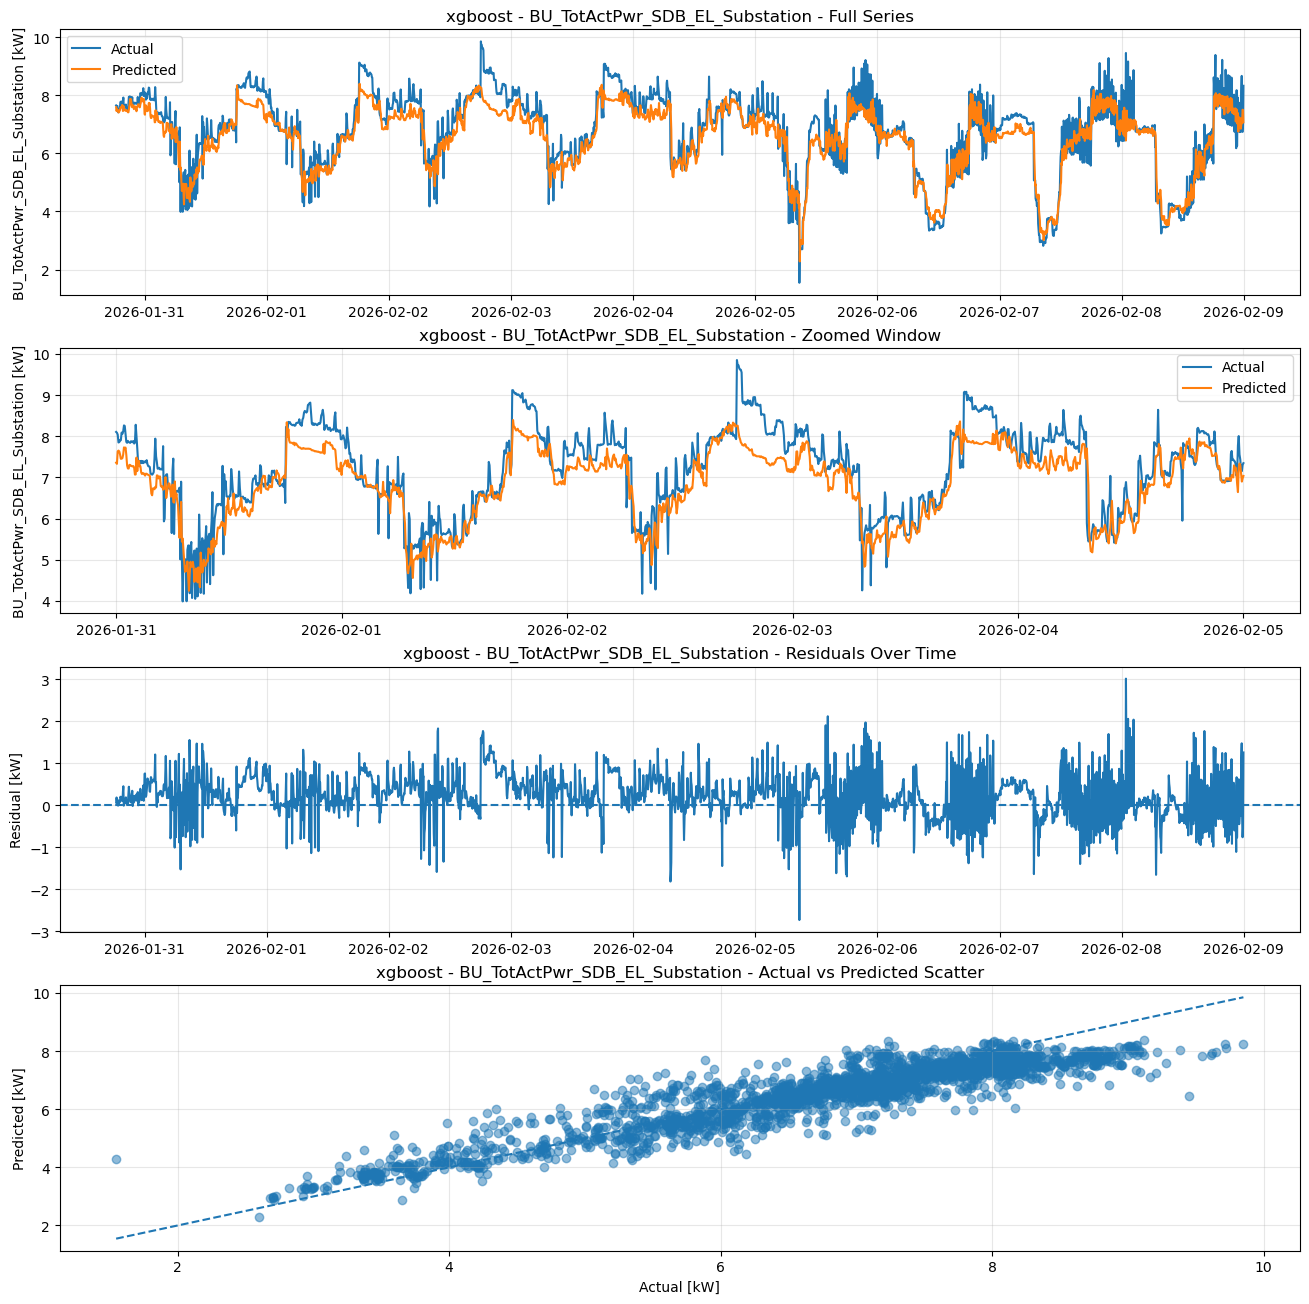

In [9]:
pred_path = results_df_nan.loc[1, "prediction_path"]
pred_df = pd.read_csv(pred_path, index_col=0, parse_dates=True)

diag = plot_forecast_diagnostics(
    predictions_df=pred_df,
    target_col=results_df_nan.loc[1, "target"],
    model_name=results_df_nan.loc[1, "model_name"],
    zoom_start="2026-01-31",
    zoom_end="2026-02-05",
)

catboost - BU_TotActPwr_SDB_EL_Substation
Total samples           : 2658
Mean absolute error     : 0.3456
Median absolute error   : 0.2208
Max absolute error      : 2.9003
Mean APE (%)            : 5.29

Worst 10 timestamps by absolute error:


,y_true,y_pred,error,abs_error,ape_percent
Time,,,,,
2026-02-08 00:50:00,9.454,6.553661,2.900339,2.900339,30.678430
2026-02-05 08:40:00,1.547,4.001286,-2.454286,2.454286,158.648105
2026-02-05 14:15:00,8.172,6.178881,1.993119,1.993119,24.389606
2026-02-08 01:15:00,9.161,7.192164,1.968836,1.968836,21.491495
2026-02-06 21:35:00,8.101,6.272903,1.828097,1.828097,22.566309
2026-02-08 18:05:00,8.615,6.826347,1.788653,1.788653,20.762079
2026-02-08 14:10:00,6.187,4.402439,1.784561,1.784561,28.843726
2026-02-08 02:20:00,8.863,7.085559,1.777441,1.777441,20.054619
2026-01-31 07:05:00,3.987,5.755617,-1.768617,1.768617,44.359592


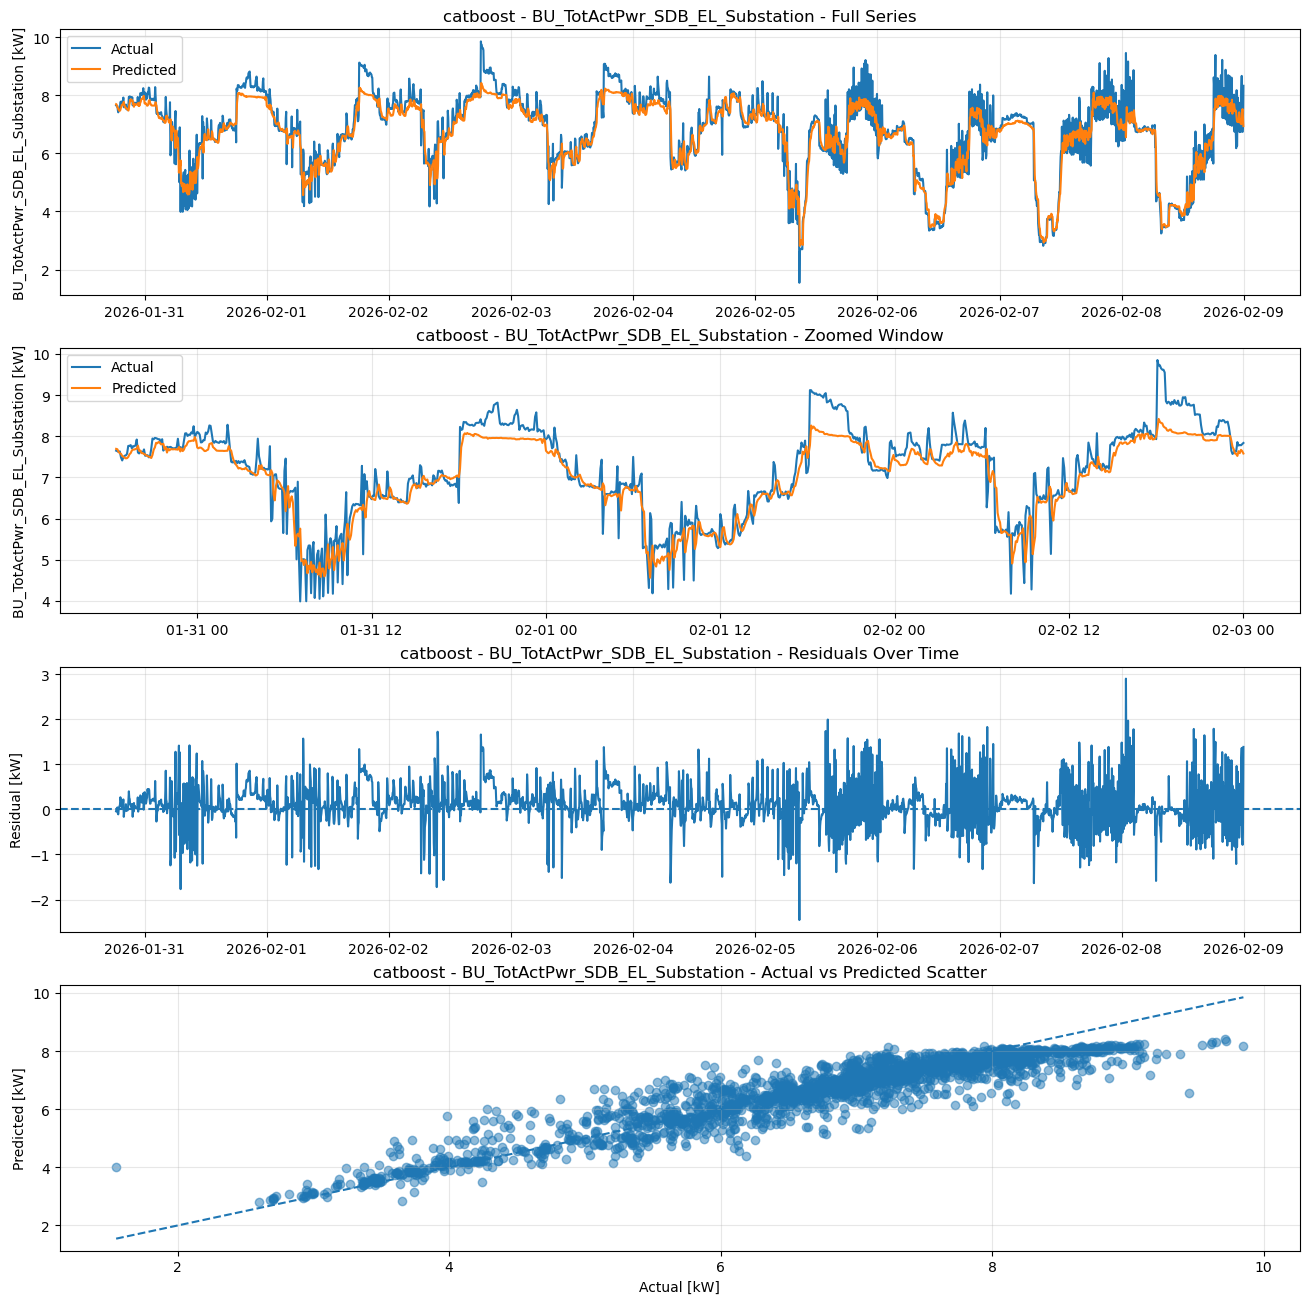

In [10]:
pred_path = results_df_nan.loc[2, "prediction_path"]
pred_df = pd.read_csv(pred_path, index_col=0, parse_dates=True)

diag = plot_forecast_diagnostics(
    predictions_df=pred_df,
    target_col=results_df_nan.loc[2, "target"],
    model_name=results_df_nan.loc[2, "model_name"],
    zoom_start="2026-01-29",
    zoom_end="2026-02-03",

)

### Residual plot

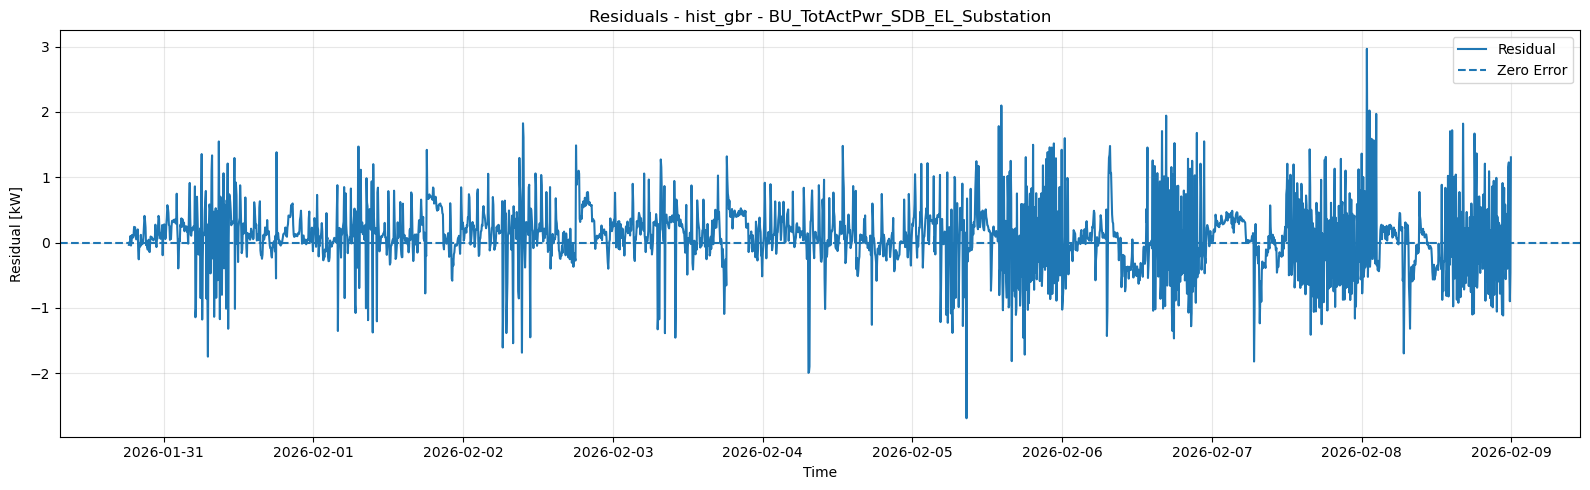

In [12]:
pred_path = results_df_nan.loc[0, "prediction_path"]
pred_df = pd.read_csv(pred_path, index_col=0, parse_dates=True)

res_df = plot_residuals(
    predictions_df=pred_df,
    target_col=results_df_nan.loc[0, "target"],
    title=f"Residuals - {results_df_nan.loc[0, 'model_name']} - {results_df_nan.loc[0, 'target']}"
)

In [13]:
results_df_nan[["model_name", "target", "prediction_path"]]

,model_name,target,prediction_path
0,hist_gbr,BU_TotActPwr_SDB_EL_Substation,C:\Data_analysis\Thesis\outputs\predictions\ru...
1,xgboost,BU_TotActPwr_SDB_EL_Substation,C:\Data_analysis\Thesis\outputs\predictions\ru...
2,catboost,BU_TotActPwr_SDB_EL_Substation,C:\Data_analysis\Thesis\outputs\predictions\ru...


In [ ]:
results_df_nan[["model_name", "target", "prediction_path"]]

,model_name,target,prediction_path
0,hist_gbr,BU_TotActPwr_SDB_EL_Substation,C:\Data_analysis\Thesis\outputs\predictions\ru...
1,xgboost,BU_TotActPwr_SDB_EL_Substation,C:\Data_analysis\Thesis\outputs\predictions\ru...
2,catboost,BU_TotActPwr_SDB_EL_Substation,C:\Data_analysis\Thesis\outputs\predictions\ru...


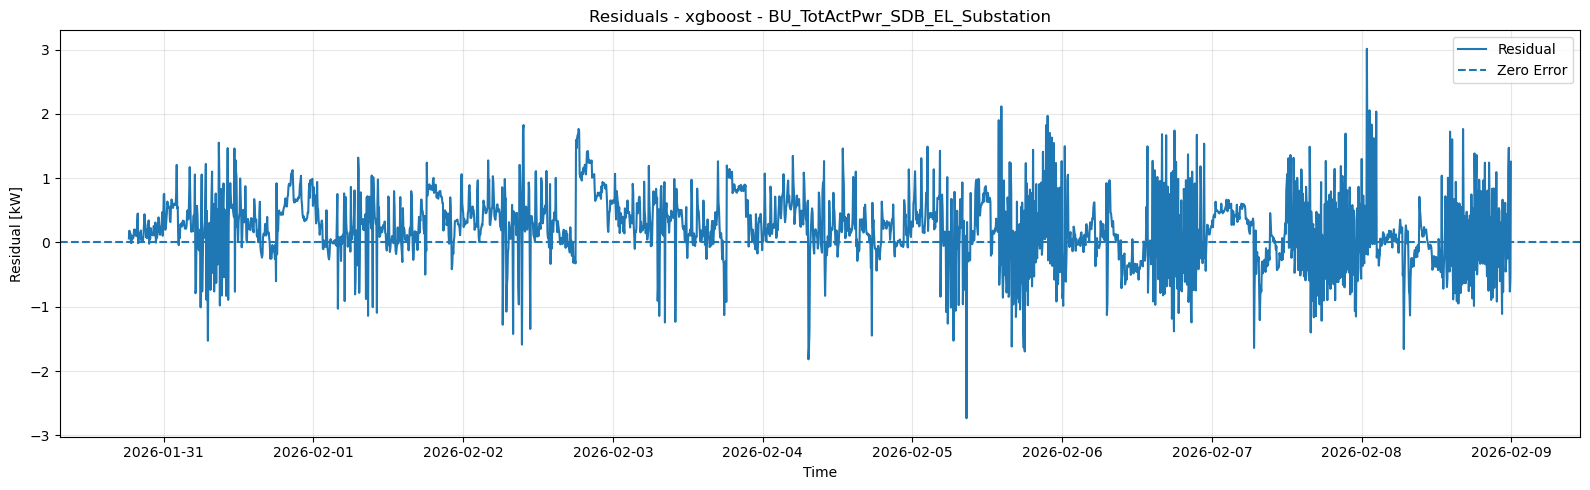

In [15]:
pred_path = results_df_nan.loc[1, "prediction_path"]
pred_df = pd.read_csv(pred_path, index_col=0, parse_dates=True)

res_df = plot_residuals(
    predictions_df=pred_df,
    target_col=results_df_nan.loc[1, "target"],
    title=f"Residuals - {results_df_nan.loc[1, 'model_name']} - {results_df_nan.loc[1, 'target']}"
)

### histogram

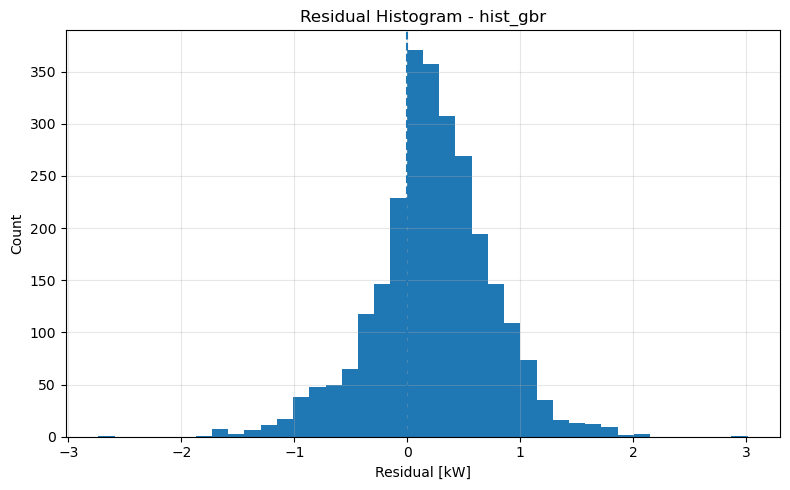

In [16]:
plot_residual_histogram(
    pred_df,
    target_col=results_df_nan.loc[0, "target"],
    title=f"Residual Histogram - {results_df_nan.loc[0, 'model_name']}"
)

### clean logs and experiments with back up

In [222]:
# from pathlib import Path
# import shutil
# from datetime import datetime
# import src.config as config

# timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
# backup_root = Path(config.PROJECT_ROOT) / "backup_experiments" / f"backup_{timestamp}"
# backup_root.mkdir(parents=True, exist_ok=True)

# paths_to_backup = {
#     "models": Path(config.MODELS_DIR),
#     "predictions": Path(config.PREDICTIONS_DIR),
#     "feature_importance": Path(config.FEATURE_IMPORTANCE_DIR),
#     "forecast_figures": Path(config.FORECAST_FIGURES_DIR),
#     "logs": Path(config.LOGS_DIR),
# }

# # backup experiment log file separately
# exp_log = Path(config.EXPERIMENT_LOG_FILE)
# if exp_log.exists():
#     shutil.copy2(exp_log, backup_root / exp_log.name)

# for name, folder in paths_to_backup.items():
#     if folder.exists():
#         dest_folder = backup_root / name
#         dest_folder.mkdir(parents=True, exist_ok=True)

#         for item in folder.iterdir():
#             shutil.move(str(item), str(dest_folder / item.name))

# print(f"Backup created at: {backup_root}")
# print("All generated outputs were moved to backup.")
# print("Source code and datasets were not touched.")

    "BU_TotActPwr_Academy",
    "BA_TotActPwr_BESS_AC_Panel1",
    "BA_TotActPwr_BESS_AC_Panel2",
    "BU_TotActPwr_Tech_Room",